<a href="https://colab.research.google.com/github/adeyemivictor091-web/Level-1-Project-1-EDA/blob/main/Level%202Project%201%20TimeSeriesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Level 2 Project1 TimeSeriesAnalysis

In [1]:
from google.colab import files

uploaded = files.upload()


Saving 2) Stock Prices Data Set.xlsx to 2) Stock Prices Data Set.xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (12,6)



In [4]:
df = pd.read_excel('2) Stock Prices Data Set.xlsx')

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [9]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.set_index('date', inplace=True)

In [12]:
df.head()


,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


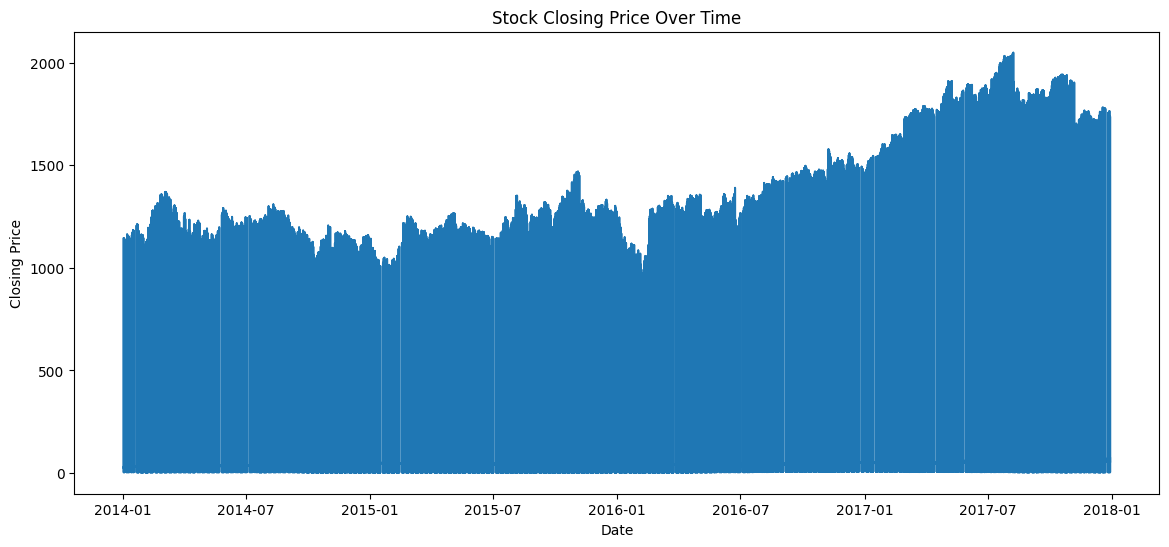

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df['close'])

plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [20]:
result = seasonal_decompose(
    df['close'],
    model='additive',
    period=30
)

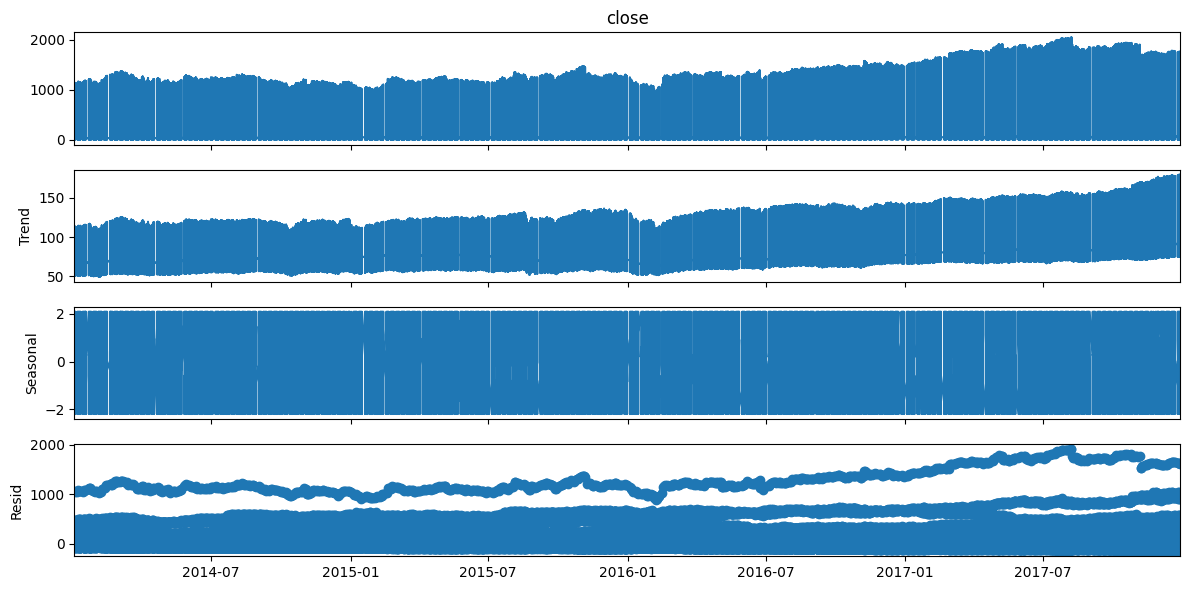

In [21]:
result.plot()

plt.show()

In [25]:
df['Moving_Average'] = (
    df['close']
    .rolling(window=30)
    .mean()
)

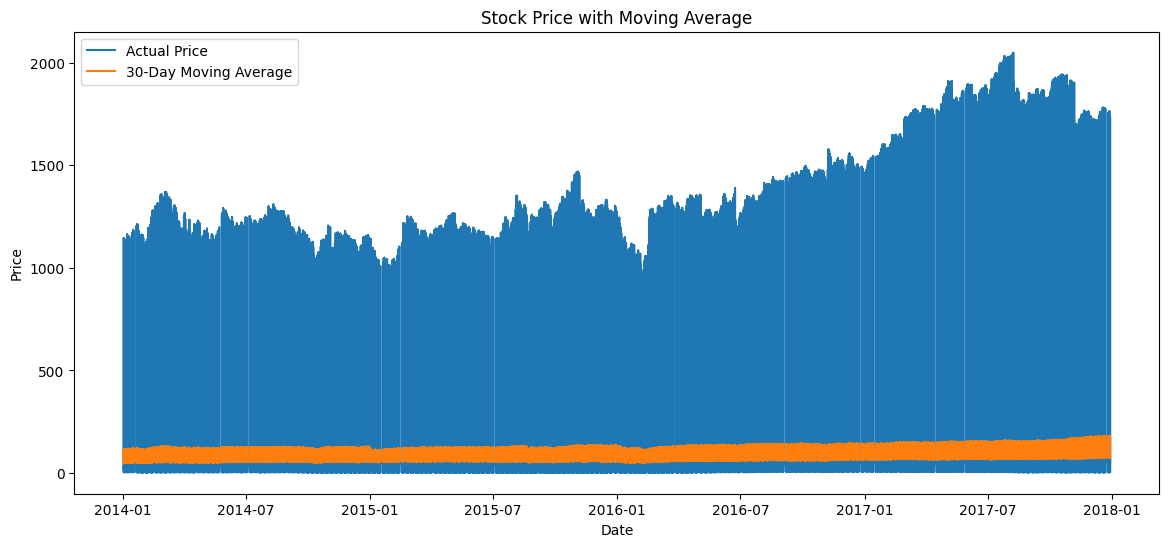

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    df['close'],
    label='Actual Price'
)

plt.plot(
    df['Moving_Average'],
    label='30-Day Moving Average'
)

plt.title('Stock Price with Moving Average')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

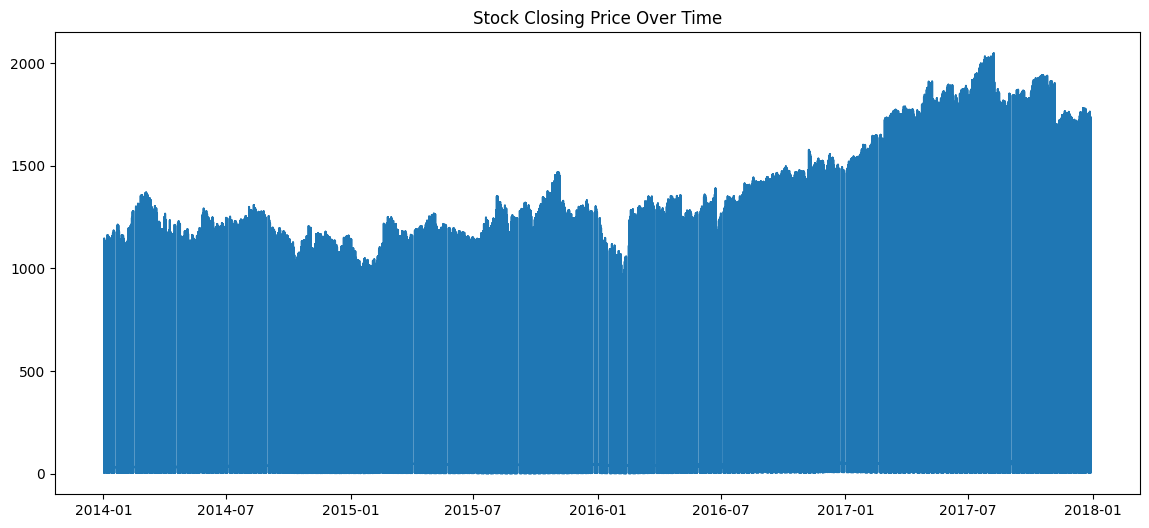

In [29]:
plt.figure(figsize=(14,6))

plt.plot(df['close'])

plt.title('Stock Closing Price Over Time')

plt.savefig('TimeSeriesPlot.png')

plt.show()

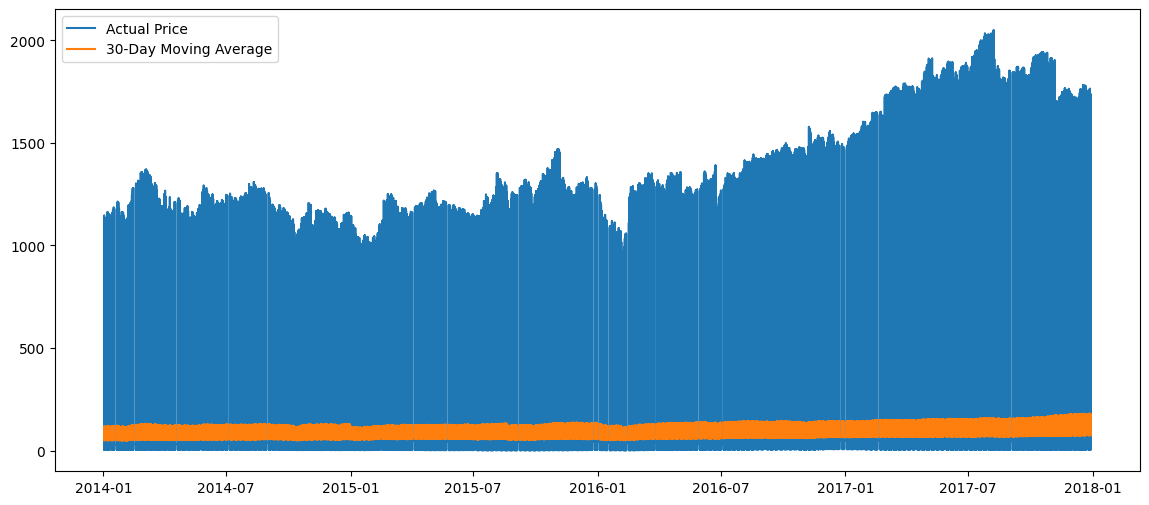

In [31]:
plt.figure(figsize=(14,6))

plt.plot(df['close'], label='Actual Price')

plt.plot(
    df['Moving_Average'],
    label='30-Day Moving Average'
)

plt.legend()

plt.savefig('MovingAveragePlot.png')

plt.show()

In [32]:
from google.colab import files

files.download('TimeSeriesPlot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
files.download('MovingAveragePlot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 497472 entries, 2014-01-02 to 2017-12-29
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   symbol          497472 non-null  object 
 1   open            497461 non-null  float64
 2   high            497464 non-null  float64
 3   low             497464 non-null  float64
 4   close           497472 non-null  float64
 5   volume          497472 non-null  int64  
 6   Moving_Average  497443 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 30.4+ MB


In [36]:
df[df['symbol'] == 'AAPL']

,symbol,open,high,low,close,volume,Moving_Average
date,,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957,NaN
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870,63.015177
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151,62.977807
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766,62.810687
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685,63.548487
...,...,...,...,...,...,...,...
2017-12-22,AAPL,174.6800,175.4240,174.5000,175.0100,16349444,86.526000
2017-12-26,AAPL,170.8000,171.4700,169.6790,170.5700,33185536,86.385667
2017-12-27,AAPL,170.1000,170.7800,169.7100,170.6000,21498213,86.408000


In [38]:
aapl = df[df['symbol'] == 'AAPL'].copy()

In [39]:
aapl.head()

,symbol,open,high,low,close,volume,Moving_Average
date,,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957,NaN
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870,63.015177
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151,62.977807
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766,62.810687
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685,63.548487


In [41]:
aapl.shape

(1007, 7)

In [43]:
aapl = aapl.sort_index()

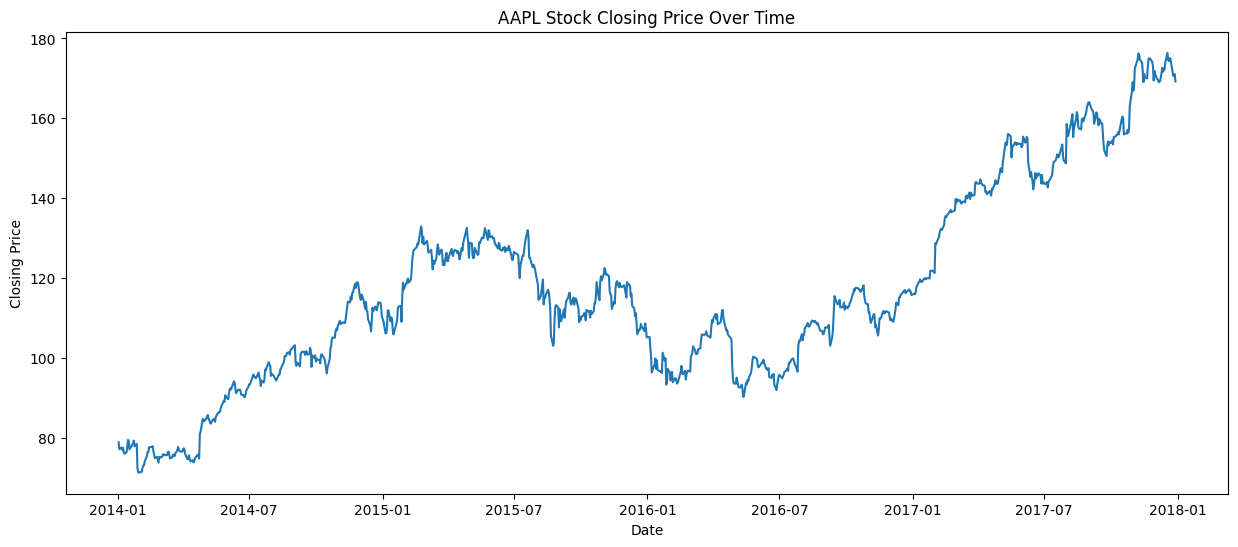

In [44]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl['close']
)

plt.title('AAPL Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    aapl['close'],
    model='additive',
    period=30
)

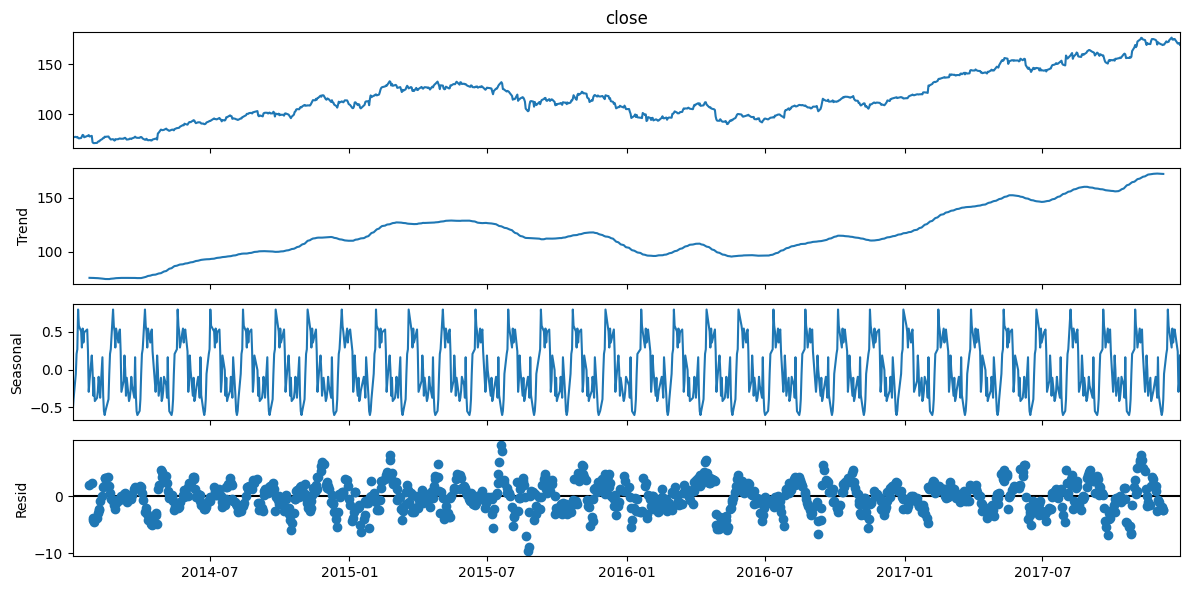

In [47]:
decomposition.plot()

plt.show()

In [49]:
aapl['Moving_Average'] = (
    aapl['close']
    .rolling(window=30)
    .mean()
)

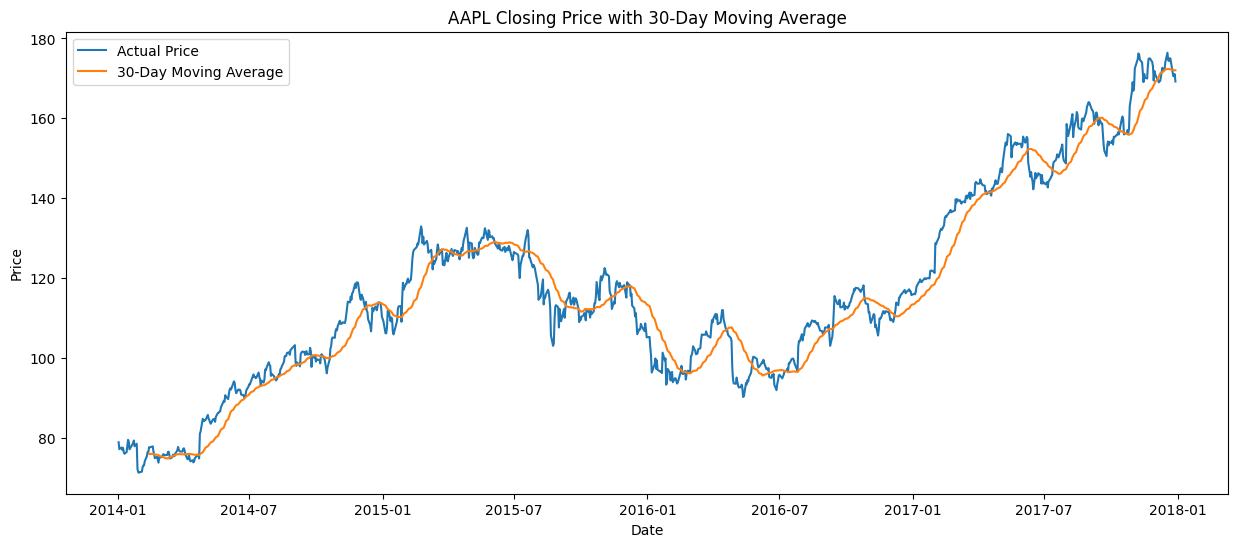

In [55]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl['close'],
    label='Actual Price'
)

plt.plot(
    aapl.index,
    aapl['Moving_Average'],
    label='30-Day Moving Average'
)

plt.title('AAPL Closing Price with 30-Day Moving Average')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.savefig('AAPL_MovingAverage.png')

plt.show()

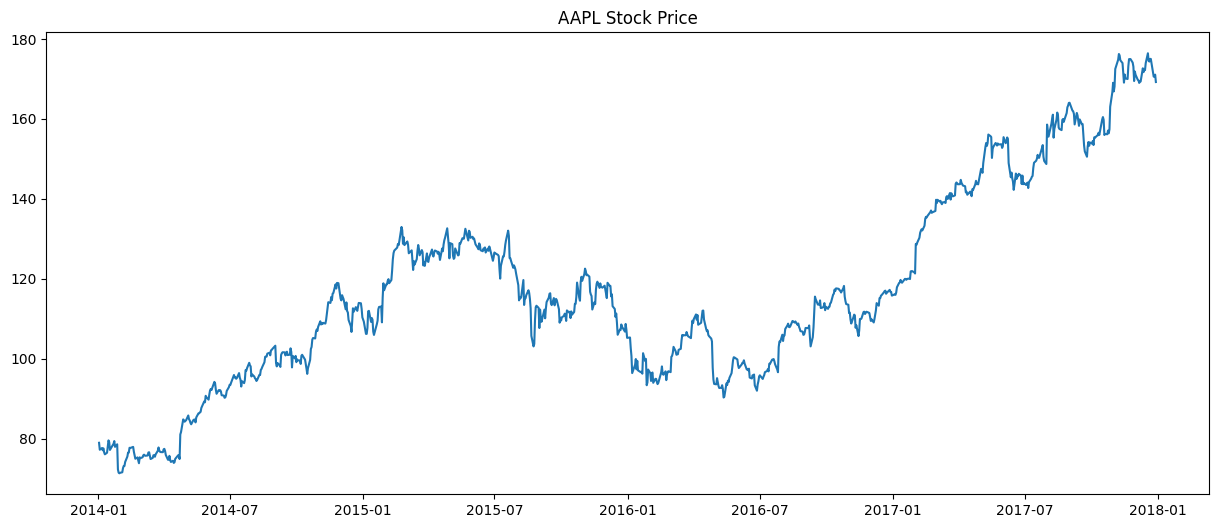

In [51]:
plt.figure(figsize=(15,6))

plt.plot(aapl.index, aapl['close'])

plt.title('AAPL Stock Price')

plt.savefig('AAPL_TimeSeries.png')

plt.show()

In [52]:
from google.colab import files

files.download('AAPL_TimeSeries.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from google.colab import files

files.download('AAPL_MovingAverage.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>